In [1]:
import pandas as pd

Carribean_temp = '~/Desktop/ISAT-Semester-Project/Data/Carribean Water temp.csv'

# We add 'skiprows' to bypass the messy titles 
# and 'names' to give the columns clear labels.
ds = pd.read_csv(
    Carribean_temp, 
    sep=None, 
    engine='python', 
    skiprows=4, 
    names=['Date_Raw', 'Anomaly']
)

# Optional: Clean up the Date column
# Converts '185012' into a proper '1850-12-01' date format
ds['Date'] = pd.to_datetime(ds['Date_Raw'].astype(str), format='%Y%m')

print(ds.head())

   Date_Raw  Anomaly       Date
0    185012     0.16 1850-12-01
1    185101     0.18 1851-01-01
2    185102     0.18 1851-02-01
3    185103     0.17 1851-03-01
4    185104     0.18 1851-04-01


In [2]:
columns_to_keep = ['Date','Anomaly']
ds = ds[columns_to_keep]
ds

,Date,Anomaly
0,1850-12-01,0.16
1,1851-01-01,0.18
2,1851-02-01,0.18
3,1851-03-01,0.17
4,1851-04-01,0.18
...,...,...
2084,2024-08-01,1.34
2085,2024-09-01,1.34
2086,2024-10-01,1.34
2087,2024-11-01,1.34


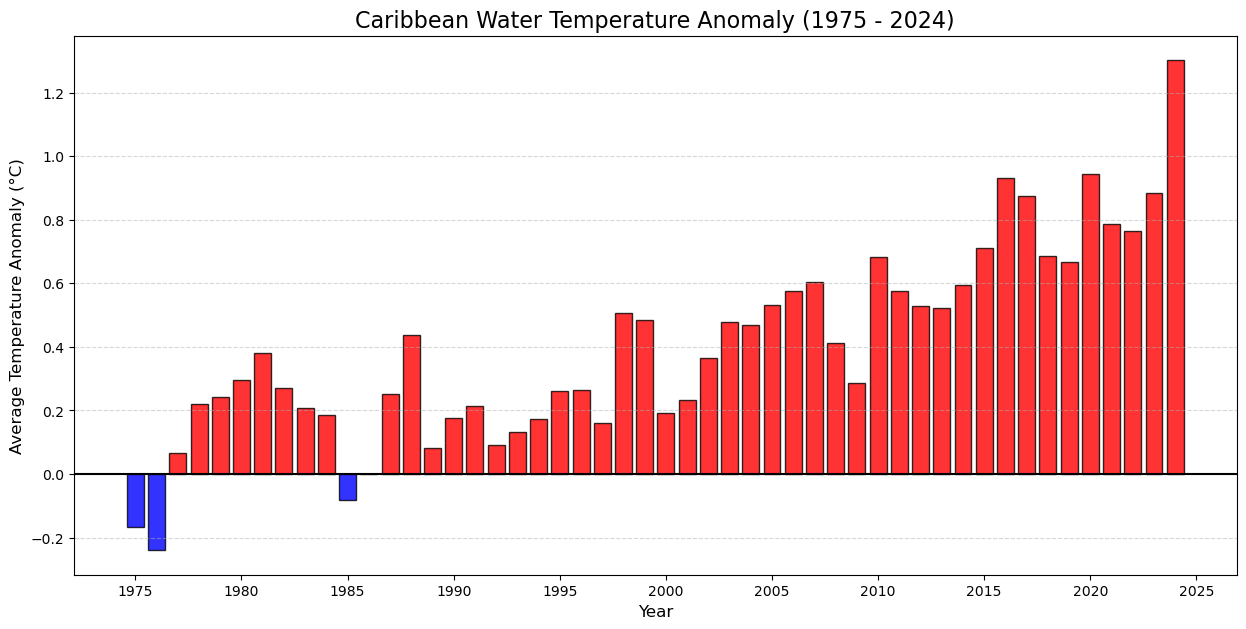

In [4]:
import matplotlib.pyplot as plt

# 1. Filter the data to include only 1975 onwards
ds_filtered = ds[ds['Date'].dt.year >= 1975]

# 2. Group by year to get the average anomaly for each year
# This makes the bar chart readable (50 bars instead of 600)
yearly_avg = ds_filtered.groupby(ds_filtered['Date'].dt.year)['Anomaly'].mean().reset_index()
yearly_avg.columns = ['Year', 'Avg_Anomaly']

# 3. Create the bar plot
plt.figure(figsize=(15, 7))

# Logic: Color the bars red if above 0 (warm) and blue if below 0 (cool)
colors = ['red' if x > 0 else 'blue' for x in yearly_avg['Avg_Anomaly']]

plt.bar(yearly_avg['Year'], yearly_avg['Avg_Anomaly'], color=colors, edgecolor='black', alpha=0.8)

# 4. Styling the graph
plt.title('Caribbean Water Temperature Anomaly (1975 - 2024)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature Anomaly (°C)', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)  # The 0.0 baseline
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Set x-ticks to show every 5 years for clarity
plt.xticks(range(1975, 2026, 5))

plt.show()